 Titanic Survival Prediction Project
  Objective:
 Build and compare multiple machine learning models to predict passenger survival
 on the Titanic dataset, and evaluate them using multiple performance metrics.
 This project uses machine learning to predict whether a passenger survived
 the Titanic disaster based on features like age, gender, class, etc.

In [100]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

 Loading dataset
 Dataset used is Titanic dataset

In [101]:
#loading dataset
df = pd.read_csv("titanic.csv")
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


DATA CLEANING:
Removing unnecessary and handling missing values

In [102]:
# Drop 'alive' column as it is redundant (duplicate of 'survived')
df.drop(['alive'], axis=1, inplace=True)
# Filling missing values with the mean of the age values
df['age'].fillna(df['age'].median(), inplace=True)
#Filling missing embarked values with mode (most frequent category)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

/tmp/ipykernel_7682/3063568479.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/tmp/ipykernel_7682/3063568479.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

Feature Engineering
Creating new features:

family_size = number of family members onboard

is_alone = whether passenger is traveling alone

In [103]:
df['family_size'] = df['sibsp'] + df['parch']
# Insight: Passengers traveling alone had different survival probabilities
df['is_alone'] = (df['family_size'] == 0).astype(int)

Converting categorical variables into numerical form using one-hot encoding

In [104]:
df = pd.get_dummies(df, drop_first=True)
df.fillna(0, inplace=True)

Feature and target spliting

In [105]:
x = df.drop('survived', axis=1)
y = df['survived']

Train-Test Split

In [106]:
#spliting the dataset in 80:20 ratio
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [107]:
#choosing the models: Logistic Regression and Random Forest Classifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=7,
        random_state=42
    )
}

MODEL TRAINING

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.821229   0.800000  0.756757  0.777778  0.876448
1        Random Forest  0.832402   0.833333  0.743243  0.785714  0.885714
                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
1        Random Forest  0.832402   0.833333  0.743243  0.785714  0.885714
0  Logistic Regression  0.821229   0.800000  0.756757  0.777778  0.876448
                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
1        Random Forest  0.832402   0.833333  0.743243  0.785714  0.885714
0  Logistic Regression  0.821229   0.800000  0.756757  0.777778  0.876448


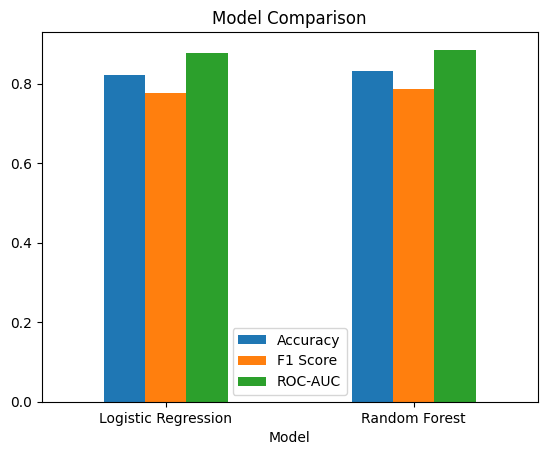

In [108]:
# Train each model and evaluate using multiple metrics:
# Accuracy, Precision, Recall, F1 Score, and ROC-AUC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
results = []
for name, m in models.items():
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)
    y_prob = m.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })
results_df = pd.DataFrame(results)
print(results_df)
print(results_df.sort_values(by="ROC-AUC", ascending=False))
print(results_df.sort_values(by="Accuracy", ascending=False))
results_df.set_index("Model")[["Accuracy", "F1 Score", "ROC-AUC"]].plot(kind="bar")
plt.title("Model Comparison")
plt.xticks(rotation=0)
plt.show()

EVALUATION

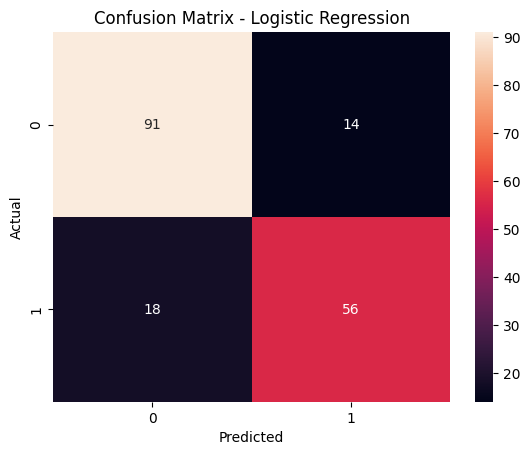

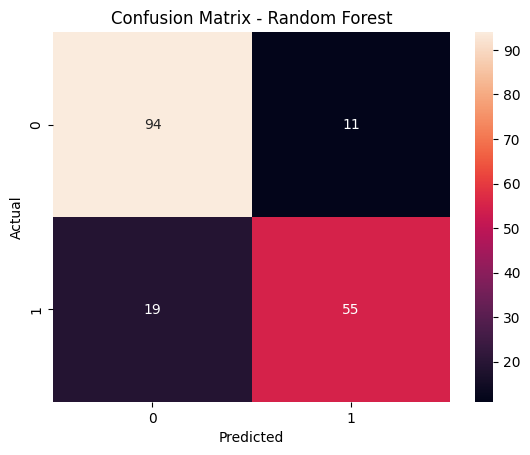

In [109]:
# Confusion Matrix Explanation:
# A confusion matrix is used to evaluate the performance of a classification model
# by comparing actual vs predicted values.
# True Positives (TP)  -> Model correctly predicts survival
# True Negatives (TN)  -> Model correctly predicts death
# False Positives (FP) -> Model predicts survival but passenger actually died
# False Negatives (FN) -> Model predicts death but passenger actually survived
from sklearn.metrics import confusion_matrix
for name, m in models.items():
    y_pred = m.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

ROC Curve
Evaluates model performance across different classification thresholds

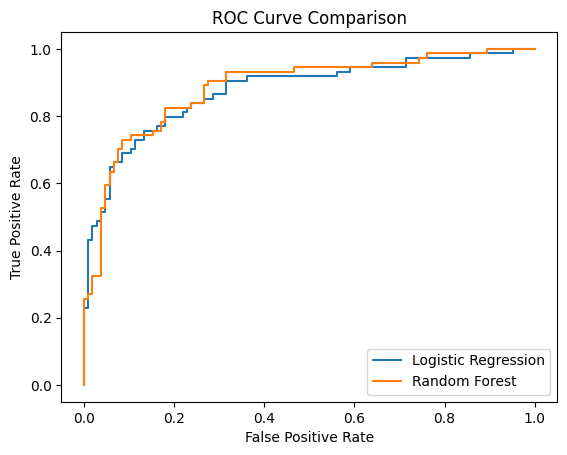

In [110]:
# ROC Curve visualizes model performance across thresholds
# A higher curve indicates better model performance
plt.figure()
for name, m in models.items():
    y_prob = m.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

Classification Report
Includes precision, recall, and F1-score for better evaluation

In [111]:
# Accuracy  -> overall correctness
# Precision -> how many predicted survivors were actually correct
# Recall    -> how many actual survivors were correctly identified
# F1 Score  -> balance between precision and recall
# ROC-AUC   -> overall model performance across all thresholds
from sklearn.metrics import classification_report
for name, m in models.items():
    y_pred = m.predict(X_test)
    print(f"\n{name} Classification Report:\n")
    print(classification_report(y_test, y_pred))


Logistic Regression Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179


Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.90      0.86       105
           1       0.83      0.74      0.79        74

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



Visualizing distribution of survival in dataset

In [112]:
# Select best model based on ROC-AUC score
best_model = results_df.sort_values(by="ROC-AUC", ascending=False).iloc[0]["Model"]
print("Best Model:", best_model)

Best Model: Random Forest


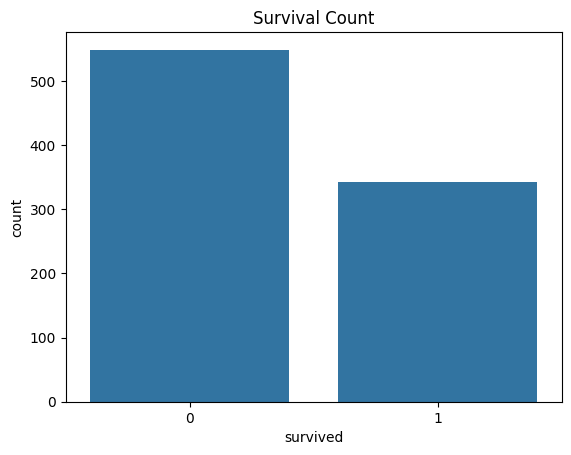

In [113]:
sns.countplot(x='survived', data=df)
plt.title("Survival Count")
plt.show()

Feature Importance
Shows which features contribute most to prediction
Important for model interpretability

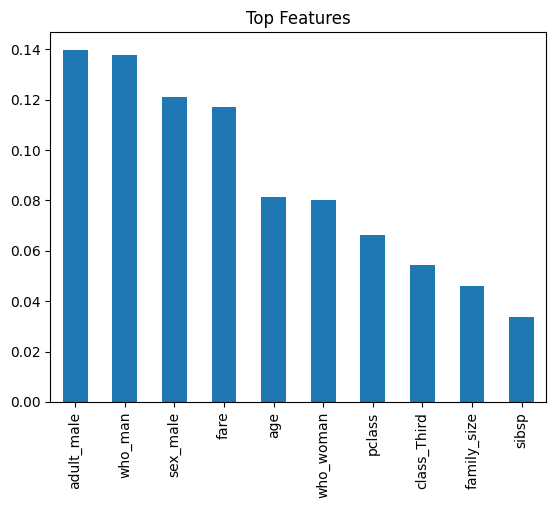

In [114]:

feature_importance = pd.Series(m.feature_importances_, index=x.columns)
feature_importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Features")
plt.show()

# Conclusion:
# In this project, we built and compared multiple machine learning models
# (Logistic Regression and Random Forest) to predict passenger survival on the Titanic dataset.

# After evaluating the models using multiple performance metrics such as Accuracy, Precision, Recall, F1 Score, and ROC-AUC, we observed that:

# - Random Forest outperformed Logistic Regression in most metrics,
#   indicating its ability to capture complex, non-linear relationships in the data.
# - Logistic Regression provided a strong baseline model with simpler assumptions and interpretable results.

# The confusion matrix and classification report helped us understand the types of errors made by each model, while the ROC curve provided insight into overall model performance.

# Feature importance analysis revealed that factors such as gender, passenger class,
# fare, and family-related features played a significant role in survival prediction.

# Overall, Random Forest was selected as the best-performing model based on ROC-AUC,making it the preferred choice for this problem.